<!-- @q -->
## Problem 1 

Using the data in the `2019_Yellow_Taxi_Trip_Data.csv` file, calculate summary statistics for the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` columns:

In [1]:
# Your code here
import os
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "data"

def top(df, n=5, title=None):
    print("\n" + ("=" * 10) + f" {title or ''} " + ("=" * 10))
    print(df.head(n))

taxi_path = os.path.join(DATA_DIR, "2019_Yellow_Taxi_Trip_Data.csv")
taxi_cols = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_distance",
    "fare_amount", "tip_amount", "tolls_amount", "total_amount"
]

taxi = pd.read_csv(
    taxi_path,
    usecols=taxi_cols,
    parse_dates=["tpep_pickup_datetime", "tpep_dropoff_datetime"],
    low_memory=False
)
money_cols = ["fare_amount", "tip_amount", "tolls_amount", "total_amount"]

p1_summary = taxi[money_cols].describe().T
print(p1_summary)
top(p1_summary, title="Problem 1 - Summary statistics (fare/tip/tolls/total)")

                count       mean        std    min     25%   50%    75%    max
fare_amount   10000.0  15.106313  13.954762 -52.00   7.000  10.0  16.00  176.0
tip_amount    10000.0   2.634494   3.409800   0.00   0.000   2.0   3.25   43.0
tolls_amount  10000.0   0.623447   6.437507  -6.12   0.000   0.0   0.00  612.0
total_amount  10000.0  22.564659  19.209255 -65.92  12.375  16.3  22.88  671.8

========== Problem 1 - Summary statistics (fare/tip/tolls/total) ==========
                count       mean        std    min     25%   50%    75%    max
fare_amount   10000.0  15.106313  13.954762 -52.00   7.000  10.0  16.00  176.0
tip_amount    10000.0   2.634494   3.409800   0.00   0.000   2.0   3.25   43.0
tolls_amount  10000.0   0.623447   6.437507  -6.12   0.000   0.0   0.00  612.0
total_amount  10000.0  22.564659  19.209255 -65.92  12.375  16.3  22.88  671.8


<!-- @q -->
## Problem 2

Isolate the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` for the longest trip by distance (`trip_distance`):

In [2]:
# Your code here
idx_longest = taxi["trip_distance"].idxmax()
p2 = taxi.loc[idx_longest, ["fare_amount", "tip_amount", "tolls_amount", "total_amount"]]
print("\n========== Problem 2 - Longest trip amounts ==========")
print(p2.to_frame("value"))



========== Problem 2 - Longest trip amounts ==========
               value
fare_amount    176.0
tip_amount     18.29
tolls_amount    6.12
total_amount  201.21


<!-- @q -->
## Problem 3 

Read in the meteorite data from the `Meteorite_Landings.csv` file, rename the `mass (g)` column to `mass`, and drop all the latitude and longitude columns. Sort the result by mass in descending order.

In [3]:
# Your code here
m_path = os.path.join(DATA_DIR, "Meteorite_Landings.csv")
data_meteor = pd.read_csv(m_path)

if "mass (g)" in data_meteor.columns:
    data_meteor = data_meteor.rename(columns={"mass (g)": "mass"})

for col in ["reclat", "reclong"]:
    if col in data_meteor.columns:
        data_meteor = data_meteor.drop(columns=col)

data_meteor["mass"] = pd.to_numeric(data_meteor["mass"], errors="coerce")
p3_sorted = data_meteor.sort_values("mass", ascending=False)

top(p3_sorted, 25, title="Problem 3 - Top 25 meteorites by mass")


========== Problem 3 - Top 25 meteorites by mass ==========
                   name     id nametype           recclass        mass   fall  \
16392              Hoba  11890    Valid          Iron, IVB  60000000.0  Found   
5373          Cape York   5262    Valid        Iron, IIIAB  58200000.0  Found   
5365    Campo del Cielo   5247    Valid       Iron, IAB-MG  50000000.0  Found   
5370      Canyon Diablo   5257    Valid       Iron, IAB-MG  30000000.0  Found   
3455            Armanty   2335    Valid         Iron, IIIE  28000000.0  Found   
12613            Gibeon  10912    Valid          Iron, IVA  26000000.0  Found   
5468         Chupaderos   5363    Valid        Iron, IIIAB  24300000.0  Found   
26297       Mundrabilla  16852    Valid      Iron, IAB-ung  24000000.0  Found   
920        Sikhote-Alin  23593    Valid         Iron, IIAB  23000000.0   Fell   
5016         Bacubirito   4919    Valid    Iron, ungrouped  22000000.0  Found   
22921             Mbosi  15456    Valid    Iron,

<!-- @q -->
## Problem 4

Using the meteorite data from the `Meteorite_Landings.csv` file, update the `year` column to only contain the year, convert it to a numeric data type, and create a new column indicating whether the meteorite was observed falling before 1970. Set the index to the `id` column and extract all the rows with IDs between 10,036 and 10,040 (inclusive) with `loc[]`.

**Hint 1**: Use `year.str.slice()` to grab a substring.

**Hint 2**: Make sure to sort the index before using `loc[]` to select the range.

In [4]:
# Your code here
data_meteor["year"] = pd.to_datetime(data_meteor["year"], errors="coerce").dt.year

data_meteor["observed_fall_before_1970"] = (data_meteor["fall"].str.upper() == "FELL") & (data_meteor["year"] < 1970)
#print(m3[m3['id']==426])
#print(m3['year'].unique())
m1 = data_meteor.set_index("id").sort_index()
m2=m1.loc[10036:10040]
print(m2)

            name nametype         recclass      mass   fall    year  \
id                                                                    
10036     Enigma    Valid               H4      94.0  Found  1967.0   
10037       Enon    Valid  Iron, ungrouped     763.0  Found  1883.0   
10038      Enshi    Valid               H5    8000.0   Fell  1974.0   
10039  Ensisheim    Valid              LL6  127000.0   Fell     NaN   

                 GeoLocation  observed_fall_before_1970  
id                                                       
10036  (31.33333, -82.31667)                      False  
10037     (39.86667, -83.95)                      False  
10038          (30.3, 109.5)                      False  
10039       (47.86667, 7.35)                      False  


/tmp/ipykernel_2059/1357796061.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_meteor["year"] = pd.to_datetime(data_meteor["year"], errors="coerce").dt.year


**BONUS**: There's a data entry error in the `year` column. Can you find it?

In [5]:
# Your code here
#Data entry error: Ensisheim (id 10039) has 'Fell' but missing year

There's a meteorite that was reportedly found in the future:

In [6]:
# Your code here
current_year = datetime.now().year

future_rows = data_meteor.loc[data_meteor["year"] > current_year, ["id", "name", "year", "fall"]]
len(future_rows)
print(future_rows)


          id                   name    year   fall
30682  57150  Northwest Africa 7701  2101.0  Found


_This meteorite actually was found in 2010 (more information [here](https://www.lpi.usra.edu/meteor/metbull.php?code=57150))._

<!-- @q -->
## Problem 5

Using the taxi trip data in the `2019_Yellow_Taxi_Trip_Data.csv` file, resample the data to an hourly frequency based on the dropoff time. Calculate the total `trip_distance`, `fare_amount`, `tolls_amount`, and `tip_amount`, then find the 5 hours with the most tips.

In [7]:
taxi_idx = taxi.set_index("tpep_dropoff_datetime")
hourly = (
    taxi_idx
    .resample("h")[["trip_distance", "fare_amount", "tolls_amount", "tip_amount"]]
    .sum(min_count=1)
)
top5_tip_hours = hourly.sort_values("tip_amount", ascending=False).head(5)

top(top5_tip_hours, title="Problem 5 - Top 5 hours by tips")



========== Problem 5 - Top 5 hours by tips ==========
                       trip_distance  fare_amount  tolls_amount  tip_amount
tpep_dropoff_datetime                                                      
2019-10-23 16:00:00         10676.95     67797.76        699.04    12228.64
2019-10-23 17:00:00         16052.83     70131.91       4044.04    12044.03
2019-10-23 18:00:00          3104.56     11565.56       1454.67     1907.64
2019-10-23 15:00:00            14.34       213.50          0.00       51.75
2019-10-23 19:00:00            98.59       268.00         24.48       25.74


<!-- @q -->
## Problem 6

Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create box plots for traveler throughput for each year in the data. Hint: Pass `kind='box'` into the `plot()` method to generate box plots.

travelers    Axes(0.125,0.11;0.775x0.77)
dtype: object

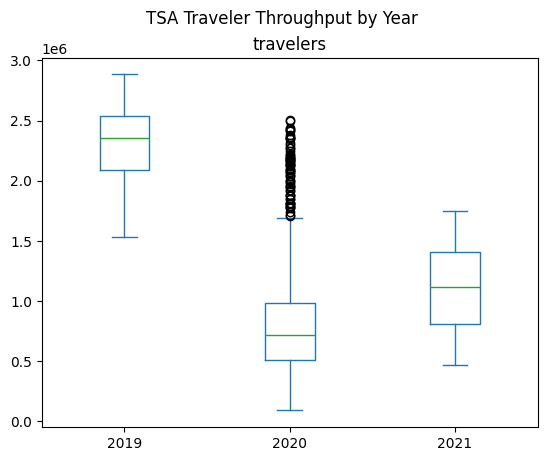

In [8]:

tsa_df = pd.read_csv(os.path.join(DATA_DIR, "tsa_melted_holiday_travel.csv"))
tsa_df.plot(
    kind="box",
    column="travelers",
    by="year",
    title="TSA Traveler Throughput by Year"
)


<!-- @q -->
## Problem 7
Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create a heatmap that shows the 2019 TSA median traveler throughput by day of week and month.

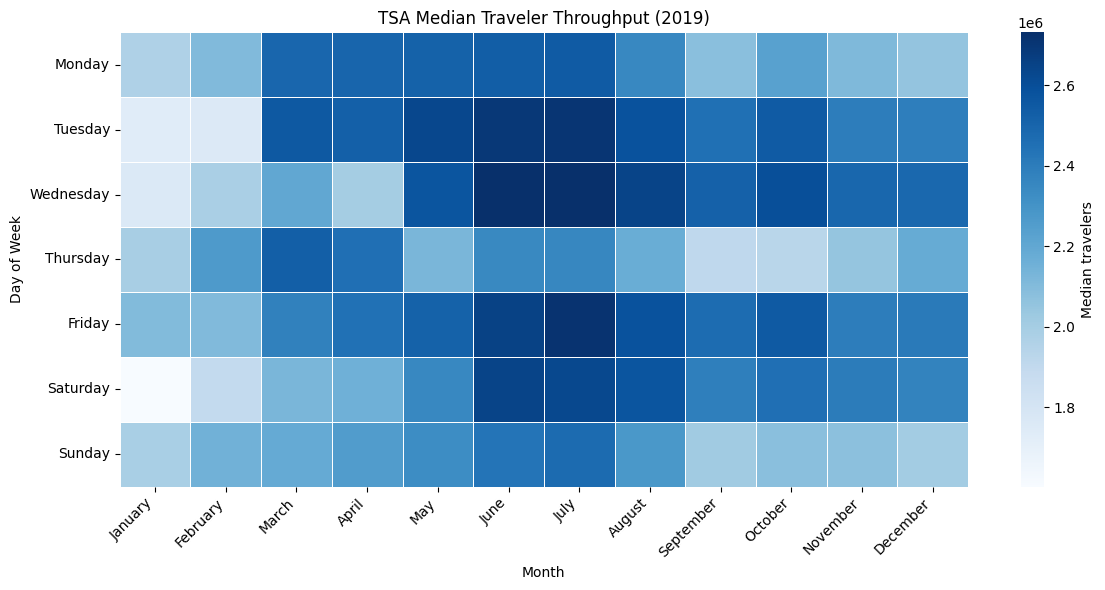

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

tsa_2019 = tsa_df.loc[tsa_df["year"] == 2019].copy()
tsa_2019["date"] = pd.to_datetime(tsa_2019["date"], errors="coerce")
tsa_2019["month"] = tsa_2019["date"].dt.month_name()
tsa_2019["weekday"] = tsa_2019["date"].dt.day_name()
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

heatmap_tbl = (
    tsa_2019
    .groupby(["weekday","month"])["travelers"].median()
    .unstack("month")
    .reindex(index=day_order, columns=month_order)
)

# plot 
plt.figure(figsize=(12,6))
sns.heatmap(
    heatmap_tbl,               
    cmap="Blues",
    annot=False,               
    linewidths=0.5,
    cbar_kws={"label": "Median travelers"}
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("TSA Median Traveler Throughput (2019)")
plt.xlabel("Month"); plt.ylabel("Day of Week")
plt.tight_layout(); plt.show()